In [24]:
import pandas as pd
import numpy as np

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [25]:
def evaluate_model(model, X_train, X_test, y_train, y_test):

    # Train
    model.fit(X_train, y_train)

    # Prediction
    y_pred = model.predict(X_test)

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        average="weighted"
    )

    recall = recall_score(
        y_test,
        y_pred,
        average="weighted"
    )

    f1 = f1_score(
        y_test,
        y_pred,
        average="weighted"
    )

    return {
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "Predictions": y_pred
    }

In [26]:
models = {

    "Multinomial Naive Bayes": MultinomialNB(),

    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=42
    ),

    "Linear SVM": LinearSVC(
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        random_state=42,
        eval_metric="mlogloss"
    )

}

In [27]:
results = []

predictions = {}

for model_name, model in models.items():

    print("="*60)
    print(model_name)
    print("="*60)

    metrics = evaluate_model(
        model,
        X_train_tfidf,
        X_test_tfidf,
        y_train,
        y_test
    )

    predictions[model_name] = metrics["Predictions"]

    print(f"Accuracy : {metrics['Accuracy']:.4f}")
    print(f"Precision: {metrics['Precision']:.4f}")
    print(f"Recall   : {metrics['Recall']:.4f}")
    print(f"F1 Score : {metrics['F1 Score']:.4f}")

    results.append({

        "Model": model_name,

        "Accuracy": metrics["Accuracy"],

        "Precision": metrics["Precision"],

        "Recall": metrics["Recall"],

        "F1 Score": metrics["F1 Score"]

    })

    print()

Multinomial Naive Bayes
Accuracy : 0.6965
Precision: 0.6768
Recall   : 0.6965
F1 Score : 0.6774

Logistic Regression
Accuracy : 0.7403
Precision: 0.7249
Recall   : 0.7403
F1 Score : 0.7296

Linear SVM
Accuracy : 0.7441
Precision: 0.7270
Recall   : 0.7441
F1 Score : 0.7325

Random Forest
Accuracy : 0.6937
Precision: 0.6668
Recall   : 0.6937
F1 Score : 0.6653

XGBoost
Accuracy : 0.7257
Precision: 0.7140
Recall   : 0.7257
F1 Score : 0.7178



In [28]:
results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy",
    ascending=False
)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
2,Linear SVM,0.744062,0.727022,0.744062,0.732542
1,Logistic Regression,0.740260,0.724902,0.740260,0.729565
4,XGBoost,0.725729,0.713977,0.725729,0.717825
0,Multinomial Naive Bayes,0.696458,0.676834,0.696458,0.677365
3,Random Forest,0.693750,0.666815,0.693750,0.665278


In [29]:
for model_name in models.keys():

    print("="*80)
    print(model_name)
    print("="*80)

    print(
        classification_report(
            y_test,
            predictions[model_name]
        )
    )

Multinomial Naive Bayes
              precision    recall  f1-score   support

           0       0.64      0.76      0.69      1600
           1       0.68      0.86      0.76      1600
           2       0.66      0.52      0.58      1600
           3       0.73      0.87      0.80      1600
           4       0.86      0.88      0.87      1600
           5       0.76      0.74      0.75      1600
           6       0.65      0.75      0.69      1600
           7       0.37      0.17      0.23      1600
           8       0.62      0.85      0.72      1600
           9       0.76      0.79      0.78      1600
          10       0.43      0.27      0.33      1600
          11       0.95      0.91      0.93      1600

    accuracy                           0.70     19200
   macro avg       0.68      0.70      0.68     19200
weighted avg       0.68      0.70      0.68     19200

Logistic Regression
              precision    recall  f1-score   support

           0       0.78      0.83 

In [30]:
best_model_name = results_df.iloc[0]["Model"]

print(best_model_name)

Linear SVM


In [31]:
import joblib
import os

os.makedirs("../models", exist_ok=True)

best_model = models[best_model_name]

joblib.dump(
    best_model,
    "../models/best_model.pkl"
)

['../models/best_model.pkl']

Hyperparameter Tuning

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import LinearSVC

param_grid = {
    "C": [0.01, 0.1, 1, 5, 10]
}

grid = GridSearchCV(
    estimator=LinearSVC(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

grid.fit(X_train_tfidf, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'C': 1}
Best CV Score: 0.7331895675718918


In [33]:
y_pred = best_model.predict(X_test_tfidf)

In [34]:
errors = pd.DataFrame({
    "text": X_test.reset_index(drop=True),
    "actual": label_encoder.inverse_transform(y_test.reset_index(drop=True)),
    "predicted": label_encoder.inverse_transform(y_pred)
})

errors = errors[
    errors["actual"] != errors["predicted"]
]

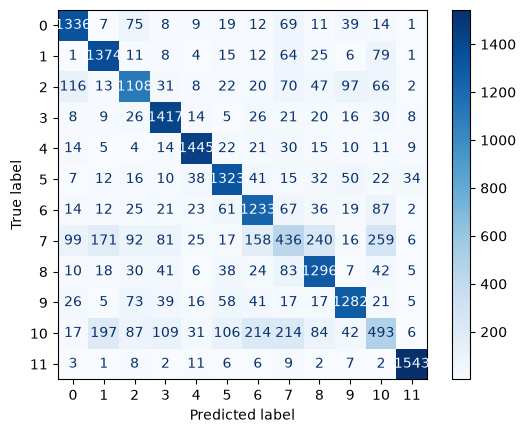

In [35]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test_tfidf,
    y_test,
    cmap="Blues"
)

plt.show()

In [36]:
import joblib

joblib.dump(best_model, "../models/linear_svm.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")
joblib.dump(label_encoder, "../models/label_encoder.pkl")

['../models/label_encoder.pkl']

In [37]:
def predict_news(text):
    vector = tfidf.transform([text])
    prediction = best_model.predict(vector)[0]
    return label_encoder.inverse_transform([prediction])[0]

In [52]:
news = """
काठमाडौं — आइतबार र सोमबार उच्च अंकले बढेको नेप्से पछिल्ला तीन दिन (मंगलबार, बुधबार र बिहीबार) घटेको छ । अन्तिम दिन (बिहीबार) नेप्सेमा निकै उतारचढाव देखियो ।

बजार खुलेदेखि बजारले घट्दो बाटो पछ्याएपछि करिब एक घण्टामा नेप्से १ हजार ३ सय ३५ को न्यून विन्दुमा ओर्लेको थियो । उक्त विन्दुबाट सम्हालिँदै माथि चढे पनि त्यो प्रवृत्तिलाई निरन्तरता दिन सकेन र अन्ततः ऋणात्मक अवस्थामै बन्द भयो ।
"""

print(predict_news(news))

business


In [57]:
idx = 20000

news = sample_df.loc[idx, "news_body"]

print("Actual:", sample_df.loc[idx, "category"])
print("Predicted:", predict_news(news))

Actual: economy
Predicted: economy


In [58]:
idx = 40000

news = sample_df.loc[idx, "news_body"]

print("Actual:", sample_df.loc[idx, "category"])
print("Predicted:", predict_news(news))

Actual: global
Predicted: global
